In [2]:
import numpy as np
import torch
import torch.nn as nn
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

In [3]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
torch.cuda.is_available()

False

In [5]:
TRAIN_DATA_DIR = Path("dataset/train_data")
TRAIN_DATA_ZIP = Path("train_data.zip")

def _load_npy_from_zip(zf, candidates):
    names = set(zf.namelist())
    for name in candidates:
        if name in names:
            with zf.open(name) as f:
                return np.load(f)
    raise FileNotFoundError(f"None of these files were found in {TRAIN_DATA_ZIP}: {candidates}")

def load_subtask_data(subtask, scanners):
    X_parts = []
    y_parts = []

    if TRAIN_DATA_DIR.exists():
        base = TRAIN_DATA_DIR / f"subtask{subtask}"
        for s in scanners:
            x = np.load(base / f"scanner{s}_X.npy")
            y = np.load(base / f"scanner{s}_y.npy")
            X_parts.append(x.astype(np.float32) / 255.0)
            y_parts.append(y.astype(np.int64))
    elif TRAIN_DATA_ZIP.exists():
        with zipfile.ZipFile(TRAIN_DATA_ZIP, "r") as zf:
            for s in scanners:
                prefix = f"subtask{subtask}/scanner{s}"
                train_prefix = f"train_data/subtask{subtask}/scanner{s}"
                dataset_prefix = f"dataset/train_data/subtask{subtask}/scanner{s}"
                x = _load_npy_from_zip(zf, [f"{prefix}_X.npy", f"{train_prefix}_X.npy", f"{dataset_prefix}_X.npy"])
                y = _load_npy_from_zip(zf, [f"{prefix}_y.npy", f"{train_prefix}_y.npy", f"{dataset_prefix}_y.npy"])
                X_parts.append(x.astype(np.float32) / 255.0)
                y_parts.append(y.astype(np.int64))
    else:
        raise FileNotFoundError(
            "Expected extracted training data at dataset/train_data/ or a train_data.zip file"
        )

    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)
    print(X.shape, y.shape)
    return X, y

# Load training data from subtask1/
def load_subtask1_data():
    return load_subtask_data(subtask=1, scanners=[1, 2, 3])

In [6]:
# Load training data from subtask2/
def load_subtask2_data():
    return load_subtask_data(subtask=2, scanners=range(1, 9))

In [49]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.GroupNorm(4, 16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 24, 3, padding=1),
            nn.GroupNorm(6, 24),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(24, 24, 3, padding=1),
            nn.GroupNorm(6, 24),
            nn.ReLU(),

            nn.Flatten(),
            nn.Linear(24 * 7 * 7, 10),
        )

    def forward(self, x):
        if x.max() > 1.5:
            x = x / 255.0

        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)

        return self.net(x)

In [50]:
def train_model(model, X, y, epochs=10, lr=0.001, batch_size=64):
    device = 'mps'
    print(f"Training on {device}")
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    X_t = torch.from_numpy(X).to(device)
    y_t = torch.from_numpy(y).long().to(device)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(y))
        total_loss = 0.0
        for start in range(0, len(y), batch_size):
            idx = perm[start:start + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_t[idx]), y_t[idx])
            loss.backward()
            opt.step()
            total_loss += loss.item()

        model.eval()
        with torch.no_grad():
            acc = (model(X_t).argmax(1) == y_t).float().mean().item()
        print(f"  epoch {epoch:2d}: loss={total_loss:.4f}  acc={acc:.4f}")

    model.eval()
    return model.cpu()

(1500, 1, 28, 28) (1500,)


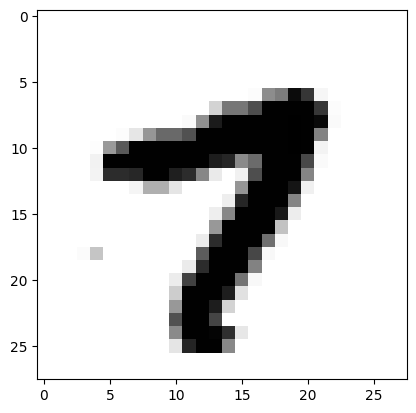

In [51]:
X1, y1 = load_subtask1_data()

plt.imshow(X1[575].squeeze(), cmap='gray')
plt.show()

(4000, 3, 28, 28) (4000,)


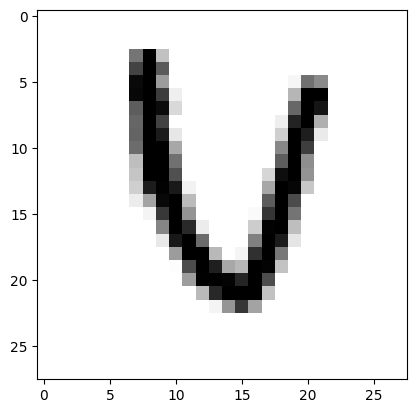

np.int64(0)

In [52]:
X2, y2 = load_subtask2_data()

plt.imshow(X2[3873].transpose(1, 2, 0), cmap='gray')
plt.show()

y2[3500]

In [53]:
# Train Subtask 1 starter model
model1 = SimpleCNN()
params1 = sum(p.numel() for p in model1.parameters())
print(f"  params: {params1:,}")
model1 = train_model(model1, X1, y1, epochs=30)

  params: 21,034
Training on mps
  epoch  0: loss=49.3703  acc=0.6767
  epoch  1: loss=25.5545  acc=0.8700
  epoch  2: loss=11.1310  acc=0.9360
  epoch  3: loss=6.0834  acc=0.9613
  epoch  4: loss=3.9730  acc=0.9847
  epoch  5: loss=2.6323  acc=0.9933
  epoch  6: loss=1.9096  acc=0.9933
  epoch  7: loss=1.5140  acc=0.9987
  epoch  8: loss=1.1194  acc=0.9993
  epoch  9: loss=0.8115  acc=1.0000
  epoch 10: loss=0.6306  acc=1.0000
  epoch 11: loss=0.5069  acc=1.0000
  epoch 12: loss=0.4046  acc=1.0000
  epoch 13: loss=0.3417  acc=1.0000
  epoch 14: loss=0.2914  acc=1.0000
  epoch 15: loss=0.2424  acc=1.0000
  epoch 16: loss=0.2188  acc=1.0000
  epoch 17: loss=0.1900  acc=1.0000
  epoch 18: loss=0.1789  acc=1.0000
  epoch 19: loss=0.1600  acc=1.0000
  epoch 20: loss=0.1387  acc=1.0000
  epoch 21: loss=0.1214  acc=1.0000
  epoch 22: loss=0.1138  acc=1.0000
  epoch 23: loss=0.1028  acc=1.0000
  epoch 24: loss=0.0953  acc=1.0000
  epoch 25: loss=0.0873  acc=1.0000
  epoch 26: loss=0.0802  acc

In [54]:
# Export Subtask 1 model with jit.script
model1.eval();
script1 = torch.jit.script(model1)
torch.jit.save(script1, "dataset/model_sub1.pt")
print(f"Exported model_sub1.pt")

Exported model_sub1.pt


In [58]:
# Train Subtask 2 starter model
model2 = SimpleCNN()
params2 = sum(p.numel() for p in model2.parameters())
print(f"  params: {params2:,}")
model2 = train_model(model2, X2, y2, epochs=30)

  params: 21,034
Training on mps
  epoch  0: loss=122.4779  acc=0.5767
  epoch  1: loss=78.5742  acc=0.7175
  epoch  2: loss=57.6560  acc=0.7782
  epoch  3: loss=47.3331  acc=0.8018
  epoch  4: loss=40.1077  acc=0.8435
  epoch  5: loss=34.6881  acc=0.8610
  epoch  6: loss=29.3897  acc=0.8923
  epoch  7: loss=26.4185  acc=0.8975
  epoch  8: loss=23.3454  acc=0.9180
  epoch  9: loss=20.4599  acc=0.9435
  epoch 10: loss=16.6293  acc=0.9555
  epoch 11: loss=14.0873  acc=0.9553
  epoch 12: loss=12.8069  acc=0.9682
  epoch 13: loss=10.2460  acc=0.9732
  epoch 14: loss=9.7473  acc=0.9732
  epoch 15: loss=8.0681  acc=0.9893
  epoch 16: loss=6.0972  acc=0.9840
  epoch 17: loss=5.3035  acc=0.9948
  epoch 18: loss=4.3163  acc=0.9942
  epoch 19: loss=3.3824  acc=0.9977
  epoch 20: loss=2.3025  acc=0.9995
  epoch 21: loss=1.8167  acc=0.9998
  epoch 22: loss=1.5300  acc=1.0000
  epoch 23: loss=1.2973  acc=1.0000
  epoch 24: loss=1.0704  acc=0.9995
  epoch 25: loss=0.9350  acc=1.0000
  epoch 26: loss

In [59]:
# Export Subtask 2 model with jit.script
model2.eval();
script2 = torch.jit.script(model2)
torch.jit.save(script2, "dataset/model_sub2.pt")
print(f"Exported model_sub2.pt")

Exported model_sub2.pt


In [60]:
# Make zip submission
with zipfile.ZipFile("dataset/submission.zip", "w") as zf:
    zf.write("dataset/model_sub1.pt")
    zf.write("dataset/model_sub2.pt")
print("Wrote submission.zip!")

Wrote submission.zip!
